# Final Dataset Comparison

Comparing OCR-cleaned original vs synthetic datasets


In [64]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt


In [65]:
orig_path = "/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_classifier/data_1000samples/original_cropped_ocr"
synth_path = "/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_classifier/data_1000samples/synthetic_fd"


In [66]:
def get_image_files(path):
    files = []
    for filename in os.listdir(path):
        if filename.endswith('.png'):
            files.append(filename)
    return sorted(files)

def compute_statistics(orig_path, synth_path, orig_files, synth_files, n_samples=100):
    orig_means = []
    orig_stds = []
    orig_sharpness = []
    orig_shapes = []
    orig_mins = []
    orig_maxs = []
    orig_dtypes = []
    
    synth_means = []
    synth_stds = []
    synth_sharpness = []
    synth_shapes = []
    synth_mins = []
    synth_maxs = []
    synth_dtypes = []
    
    for i in range(n_samples):
        if i >= len(orig_files) or i >= len(synth_files):
            break
        
        orig_file = os.path.join(orig_path, orig_files[i])
        synth_file = os.path.join(synth_path, synth_files[i])
        
        orig = cv2.imread(orig_file, cv2.IMREAD_GRAYSCALE)
        synth = cv2.imread(synth_file, cv2.IMREAD_GRAYSCALE)
        
        if orig is None or synth is None:
            continue
        
        orig_shapes.append(orig.shape)
        synth_shapes.append(synth.shape)
        
        orig_dtypes.append(str(orig.dtype))
        synth_dtypes.append(str(synth.dtype))
        
        orig_mins.append(np.min(orig))
        orig_maxs.append(np.max(orig))
        synth_mins.append(np.min(synth))
        synth_maxs.append(np.max(synth))
        
        orig_means.append(np.mean(orig))
        orig_stds.append(np.std(orig))
        
        synth_means.append(np.mean(synth))
        synth_stds.append(np.std(synth))
        
        orig_laplacian = cv2.Laplacian(orig, cv2.CV_64F)
        orig_sharpness.append(orig_laplacian.var())
        
        synth_laplacian = cv2.Laplacian(synth, cv2.CV_64F)
        synth_sharpness.append(synth_laplacian.var())
    
    stats = {
        'orig_means': orig_means,
        'orig_stds': orig_stds,
        'orig_sharpness': orig_sharpness,
        'orig_shapes': orig_shapes,
        'orig_mins': orig_mins,
        'orig_maxs': orig_maxs,
        'orig_dtypes': orig_dtypes,
        'synth_means': synth_means,
        'synth_stds': synth_stds,
        'synth_sharpness': synth_sharpness,
        'synth_shapes': synth_shapes,
        'synth_mins': synth_mins,
        'synth_maxs': synth_maxs,
        'synth_dtypes': synth_dtypes
    }
    return stats

def print_statistics(stats):
    orig_mean = np.mean(stats['orig_means'])
    synth_mean = np.mean(stats['synth_means'])
    mean_diff = abs(orig_mean - synth_mean)
    
    orig_std = np.mean(stats['orig_stds'])
    synth_std = np.mean(stats['synth_stds'])
    std_diff = abs(orig_std - synth_std)
    
    orig_sharp = np.mean(stats['orig_sharpness'])
    synth_sharp = np.mean(stats['synth_sharpness'])
    sharp_diff = abs(orig_sharp - synth_sharp)
    
    orig_shapes = set(stats['orig_shapes'])
    synth_shapes = set(stats['synth_shapes'])
    
    orig_dtypes = set(stats['orig_dtypes'])
    synth_dtypes = set(stats['synth_dtypes'])
    
    orig_min = min(stats['orig_mins'])
    orig_max = max(stats['orig_maxs'])
    synth_min = min(stats['synth_mins'])
    synth_max = max(stats['synth_maxs'])
    
    print("STATISTICAL COMPARISON (100 samples)")
    print()
    print("Image Shape:")
    print("  Original:", orig_shapes)
    print("  Synthetic:", synth_shapes)
    print()
    print("Data Type:")
    print("  Original:", orig_dtypes)
    print("  Synthetic:", synth_dtypes)
    print()
    print("Pixel Value Range:")
    print("  Original:", orig_min, "-", orig_max)
    print("  Synthetic:", synth_min, "-", synth_max)
    print()
    print("Brightness (Mean):")
    print("  Original:", round(orig_mean, 2))
    print("  Synthetic:", round(synth_mean, 2))
    print("  Difference:", round(mean_diff, 2))
    print()
    print("Contrast (Std):")
    print("  Original:", round(orig_std, 2))
    print("  Synthetic:", round(synth_std, 2))
    print("  Difference:", round(std_diff, 2))
    print()
    print("Sharpness:")
    print("  Original:", round(orig_sharp, 2))
    print("  Synthetic:", round(synth_sharp, 2))
    print("  Difference:", round(sharp_diff, 2))

def collect_pixel_values(orig_path, synth_path, orig_files, synth_files, n_samples=100):
    orig_pixels = []
    synth_pixels = []
    
    for i in range(n_samples):
        if i >= len(orig_files) or i >= len(synth_files):
            break
        
        orig_file = os.path.join(orig_path, orig_files[i])
        synth_file = os.path.join(synth_path, synth_files[i])
        
        orig = cv2.imread(orig_file, cv2.IMREAD_GRAYSCALE)
        synth = cv2.imread(synth_file, cv2.IMREAD_GRAYSCALE)
        
        if orig is None or synth is None:
            continue
        
        orig_pixels.extend(orig.flatten())
        synth_pixels.extend(synth.flatten())
    
    return orig_pixels, synth_pixels

def plot_histograms_separate(orig_pixels, synth_pixels):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(orig_pixels, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.title('Original - Pixel Value Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(synth_pixels, bins=50, alpha=0.7, color='red', edgecolor='black')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.title('Synthetic - Pixel Value Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_histograms_overlay(orig_pixels, synth_pixels):
    plt.figure(figsize=(10, 5))
    plt.hist(orig_pixels, bins=50, alpha=0.6, color='blue', label='Original', edgecolor='black')
    plt.hist(synth_pixels, bins=50, alpha=0.6, color='red', label='Synthetic', edgecolor='black')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.title('Pixel Value Distribution Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_side_by_side(orig_path, synth_path, orig_files, synth_files, n=20):
    fig, axes = plt.subplots(n, 2, figsize=(12, 3*n))
    
    for i in range(n):
        if i >= len(orig_files) or i >= len(synth_files):
            break
        
        orig_file = os.path.join(orig_path, orig_files[i])
        synth_file = os.path.join(synth_path, synth_files[i])
        
        orig = cv2.imread(orig_file, cv2.IMREAD_GRAYSCALE)
        synth = cv2.imread(synth_file, cv2.IMREAD_GRAYSCALE)
        
        if orig is None or synth is None:
            continue
        
        axes[i, 0].imshow(orig, cmap='gray')
        axes[i, 0].set_title(f'Original {i+1}', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(synth, cmap='gray')
        axes[i, 1].set_title(f'Synthetic {i+1}', fontsize=10)
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

orig_files = get_image_files(orig_path)
synth_files = get_image_files(synth_path)


In [67]:
print("Original:", len(orig_files))
print("Synthetic:", len(synth_files))


Original: 1000
Synthetic: 1000


In [68]:
stats = compute_statistics(orig_path, synth_path, orig_files, synth_files, n_samples=100)


In [69]:
print_statistics(stats)


STATISTICAL COMPARISON (100 samples)

Image Shape:
  Original: {(512, 512)}
  Synthetic: {(512, 512)}

Data Type:
  Original: {'uint8'}
  Synthetic: {'uint8'}

Pixel Value Range:
  Original: 0 - 255
  Synthetic: 0 - 255

Brightness (Mean):
  Original: 31.45
  Synthetic: 46.11
  Difference: 14.66

Contrast (Std):
  Original: 46.71
  Synthetic: 55.3
  Difference: 8.6

Sharpness:
  Original: 67.36
  Synthetic: 696.01
  Difference: 628.65


In [70]:
orig_pixels, synth_pixels = collect_pixel_values(orig_path, synth_path, orig_files, synth_files, n_samples=100)


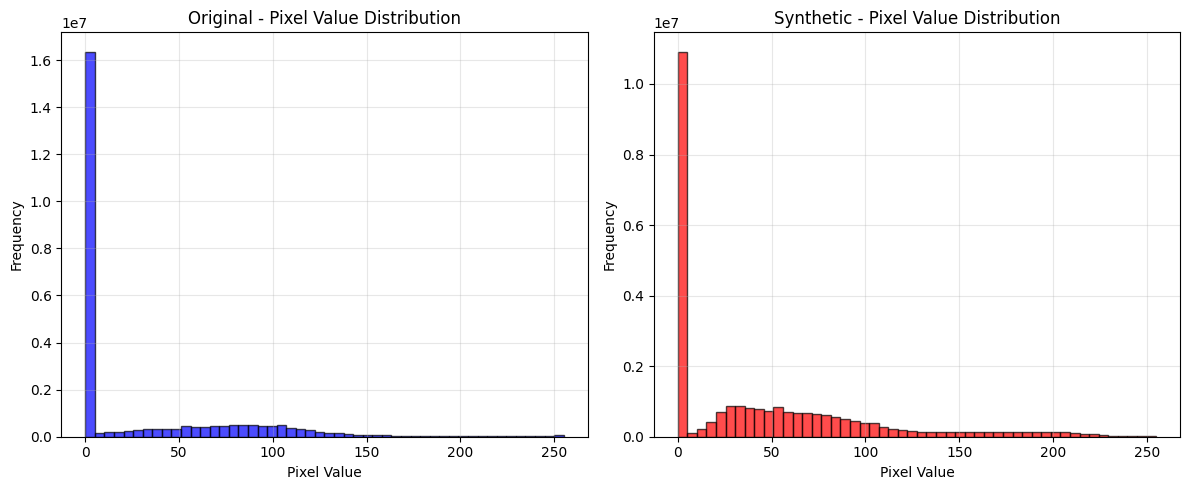

In [71]:
plot_histograms_separate(orig_pixels, synth_pixels)


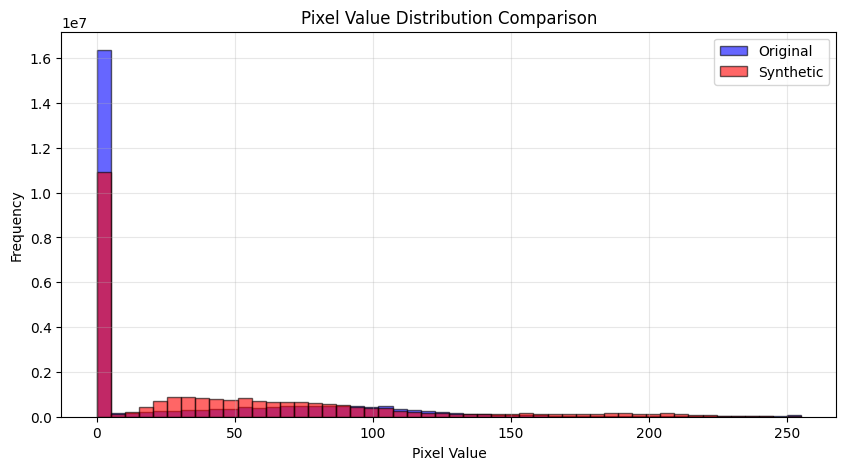

In [72]:
plot_histograms_overlay(orig_pixels, synth_pixels)


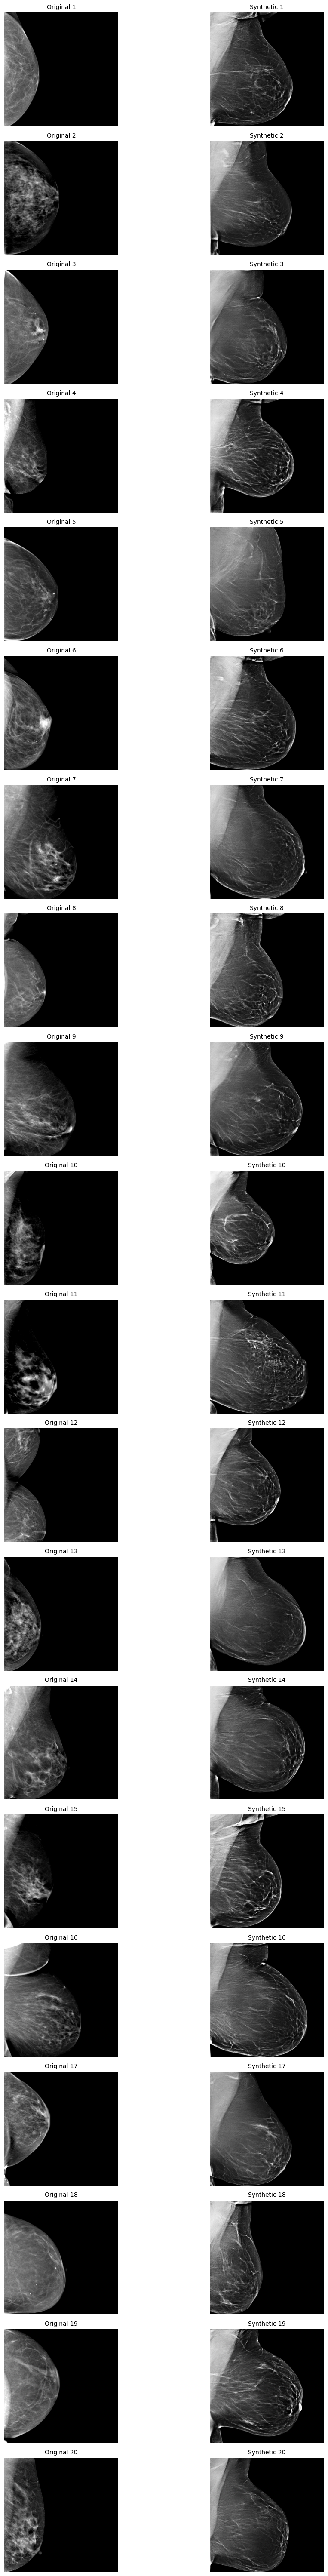

In [73]:
plot_side_by_side(orig_path, synth_path, orig_files, synth_files, n=20)
